# Import Required Libraries
Import pandas for data handling and matplotlib.pyplot and seaborn for plotting.

In [81]:
# Import Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Enable inline plotting for Jupyter
%matplotlib inline

# Load CSV File
Use pandas to read the CSV file into a DataFrame. You can change the file path below to your CSV file.

In [82]:
# Load CSV File
csv_path = '/home/daniele/Desktop/tirocinio/energyBANERA-main/Data/new_measures/jetson_nano/Conv_3_0_nograd/Conv_1_1024_3_0.csv'  # Change this to your CSV file path
csv_path_old = '/home/daniele/Desktop/tirocinio/energyBANERA-main/Data/Jetson_nano_power_record/Conv_3_0/Conv_1_512_3_0.csv'  # Change this to your CSV file path
df = pd.read_csv(csv_path)
df_old = pd.read_csv(csv_path_old)

# Display Data Overview
Show the first few rows and basic info about the DataFrame to understand its structure.

In [83]:
# Display Data Overview
display(df.head())
df.info()
df.describe()

,Sample,EVM1 VSHUNT Results (mV),EVM1 VBUS Results (V),EVM1 CURRENT Results (A),EVM1 POWER Results (W)
0,0,1.8025,5.15125,0.150157,0.774440
1,1,1.7650,5.13750,0.206924,1.064378
2,2,1.9500,5.14125,0.144359,0.743920
3,3,1.7375,5.14750,0.144816,0.743920
4,4,1.7400,5.15750,0.131845,0.682880


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Sample                    10000 non-null  int64  
 1   EVM1 VSHUNT Results (mV)  10000 non-null  float64
 2   EVM1 VBUS Results (V)     10000 non-null  float64
 3   EVM1 CURRENT Results (A)  10000 non-null  float64
 4   EVM1 POWER Results (W)    10000 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 390.8 KB


,Sample,EVM1 VSHUNT Results (mV),EVM1 VBUS Results (V),EVM1 CURRENT Results (A),EVM1 POWER Results (W)
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4999.50000,4.725703,5.016093,0.393822,1.969513
std,2886.89568,1.309109,0.057471,0.109044,0.540282
min,0.00000,0.727500,4.990000,0.060582,0.312828
25%,2499.75000,5.147500,4.993750,0.428956,2.144015
50%,4999.50000,5.190000,4.995000,0.432465,2.163090
75%,7499.25000,5.205000,5.000000,0.433686,2.163090
max,9999.00000,5.267500,5.217500,0.439180,2.193610


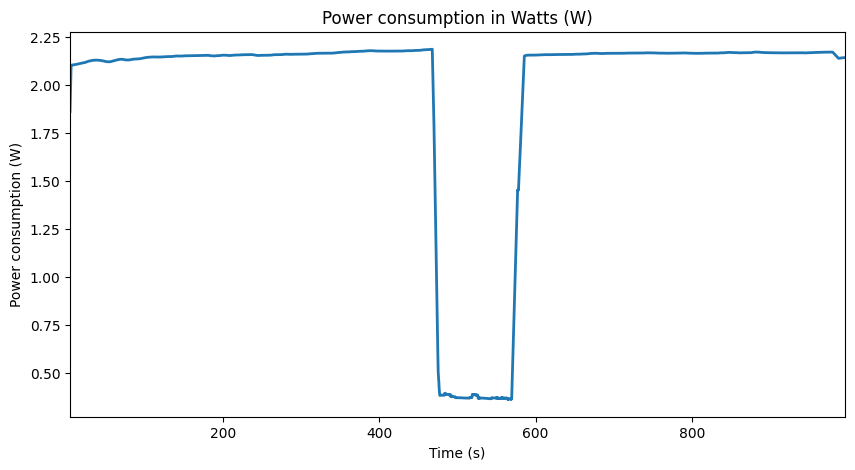

In [84]:
# Smooth the 'EVM1 POWER Results (W)' using a rolling mean
window_size = 75  # Adjust the window size as needed
smoothed = df['EVM1 POWER Results (W)'].rolling(window=window_size, center=True).mean()

smoothed = smoothed.dropna()
# Align 'Sample' values with the smoothed data index
sample_aligned = df['Sample'].iloc[smoothed.index]

time_sec = df['Sample'] * 0.1 # Assuming each sample corresponds to 0.1 seconds
#time_sec = df['Sample'] / 1000 # Assuming 'Sample' is in milliseconds, convert to seconds
time_sec_smoothed = time_sec.iloc[smoothed.index]

plt.figure(figsize=(10, 5))
plt.plot(time_sec_smoothed, smoothed, label=f'Rolling Mean (window={window_size})',linewidth=2.0)
plt.xlim(time_sec_smoothed.min(), time_sec_smoothed.max())
plt.xlabel('Time (s)')
plt.ylabel('Power consumption (W)')
plt.title('Power consumption in Watts (W)')
#plt.legend()
#plt.savefig("high_res_plot.svg",format='svg', dpi=300, bbox_inches='tight', transparent=False)
plt.show()



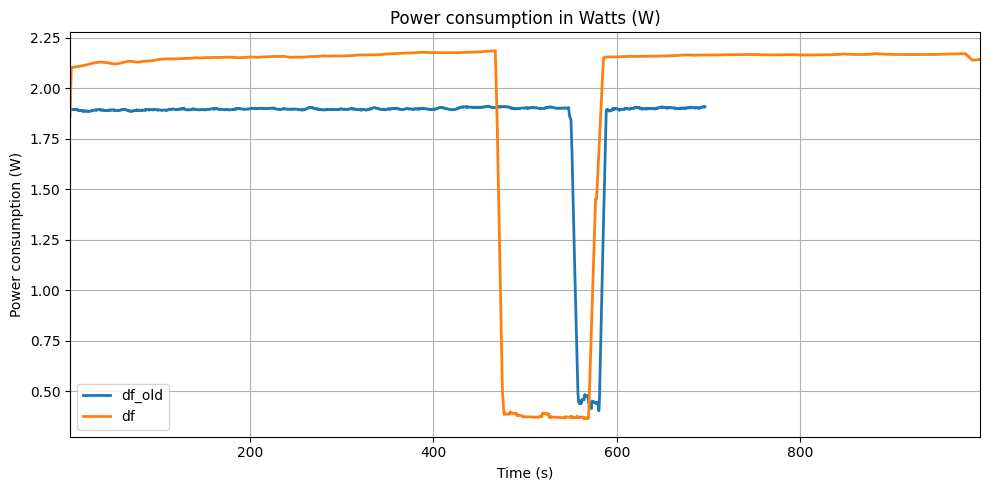

In [88]:
window_size = 75

smoothed_old = (
    df_old['EVM1 POWER Results (W)']
    .rolling(window=window_size, center=True)
    .mean()
    .dropna()
)

time_sec_old = df_old['Sample'] * 0.1
time_sec_smoothed_old = time_sec_old.iloc[smoothed_old.index]

# --- df ---
smoothed = (
    df['EVM1 POWER Results (W)']
    .rolling(window=window_size, center=True)
    .mean()
    .dropna()
)

time_sec = df['Sample'] * 0.1
time_sec_smoothed = time_sec.iloc[smoothed.index]

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    time_sec_smoothed_old,
    smoothed_old,
    label='df_old',
    linewidth=2.0
)

ax.plot(
    time_sec_smoothed,
    smoothed,
    label='df',
    linewidth=2.0
)

ax.set_xlim(
    min(time_sec_smoothed_old.min(), time_sec_smoothed.min()),
    max(time_sec_smoothed_old.max(), time_sec_smoothed.max())
)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Power consumption (W)')
ax.set_title('Power consumption in Watts (W)')
ax.legend()
plt.grid(visible=True)
plt.tight_layout()
plt.show()

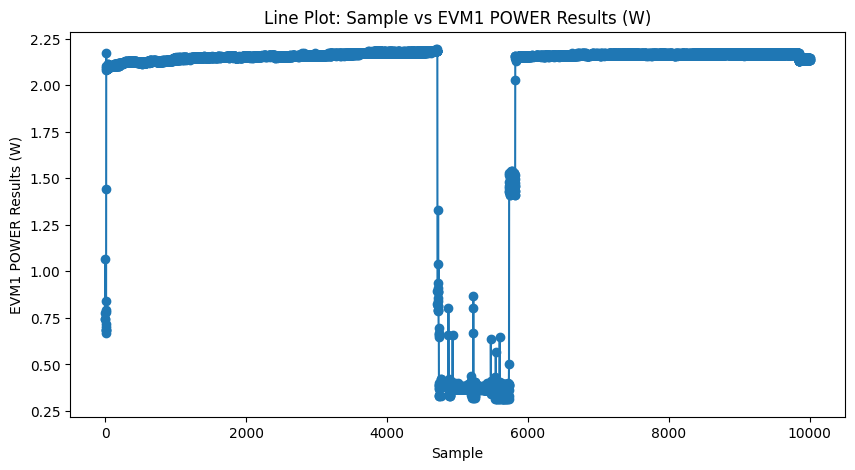

In [86]:
# Line plot: sample index (abscissa) vs 'EVM1 POWER Results' (ordinate)

plt.figure(figsize=(10, 5))
plt.plot(df['Sample'], df['EVM1 POWER Results (W)'], marker='o')
plt.xlabel('Sample')
plt.ylabel('EVM1 POWER Results (W)')
plt.title(f'Line Plot: Sample vs EVM1 POWER Results (W)')
plt.show()
